# Electrical Failure Prediction Model

Binary classification for electrical failure risk in next 30 days.

- Target: `failure_within_30_days` (0/1)
- Model: RandomForestClassifier

Run `Preprocessing-Pipeline.ipynb` first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json, warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 1. Load Data

In [2]:
df = pd.read_csv('../data/preprocessed/electrical_data.csv')
print(f'Electrical data: {df.shape}')
print(f'Target balance: {df["failure_within_30_days"].mean():.2%} positive')
df['failure_within_30_days'].value_counts()

Electrical data: (16512, 48)
Target balance: 37.05% positive


failure_within_30_days
0    10394
1     6118
Name: count, dtype: int64

## 2. Feature Selection

In [3]:
electrical_features = [
    'wiring_exposed', 'power_outage_hours_weekly', 'condition_score',
    'issue_flag', 'students_per_classroom', 'num_students',
    'weeks_since_last_repair', 'days_since_repair', 'repair_done',
    'condition_trend', 'deterioration_rate', 'urgency_score',
    'building_age', 'girls_school', 'flood_prone_area',
    'crack_width_mm', 'water_leak', 'roof_leak_flag',
]

weather_cols = [c for c in df.columns if c.startswith('weather_zone_')]
material_cols = [c for c in df.columns if c.startswith('material_type_')]
electrical_features.extend(weather_cols)
electrical_features.extend(material_cols)
electrical_features = [f for f in electrical_features if f in df.columns]

TARGET = 'failure_within_30_days'
X = df[electrical_features].fillna(0)
y = df[TARGET]

print(f'Features: {len(electrical_features)}')
print(f'X: {X.shape}, y: {y.shape}')

Features: 26
X: (16512, 26), y: (16512,)


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 13209, Test: 3303


## 4. Train Random Forest

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print('Electrical Model Results:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  F1:        {f1_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'  ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Failure','Failure']))

Electrical Model Results:
  Accuracy:  0.9997
  F1:        0.9996
  Precision: 0.9992
  Recall:    1.0000
  ROC AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      2079
     Failure       1.00      1.00      1.00      1224

    accuracy                           1.00      3303
   macro avg       1.00      1.00      1.00      3303
weighted avg       1.00      1.00      1.00      3303



In [6]:
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print(f'5-Fold CV F1: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV F1: [1. 1. 1. 1. 1.]
Mean: 1.0000 +/- 0.0000


## 5. Evaluation Plots

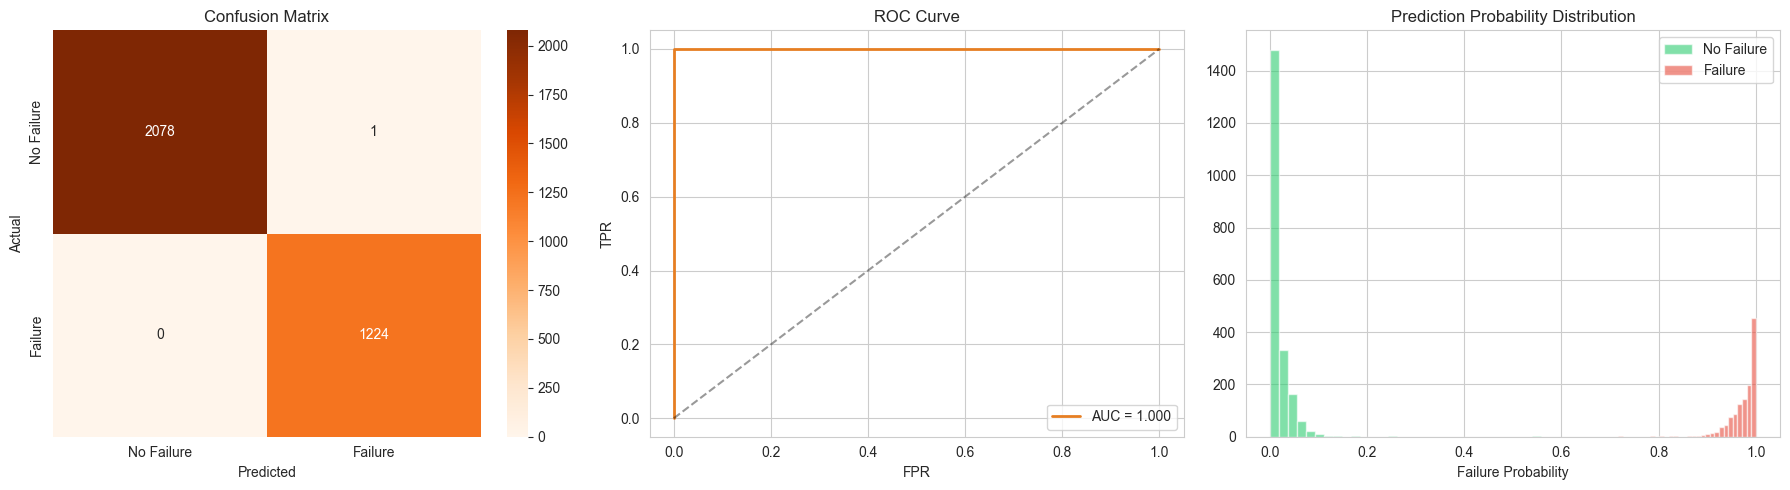

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e67e22', linewidth=2,
             label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

axes[2].hist(y_prob[y_test==0], bins=30, alpha=0.6, label='No Failure', color='#2ecc71')
axes[2].hist(y_prob[y_test==1], bins=30, alpha=0.6, label='Failure', color='#e74c3c')
axes[2].set_title('Prediction Probability Distribution')
axes[2].set_xlabel('Failure Probability')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Feature Importance and Explainability

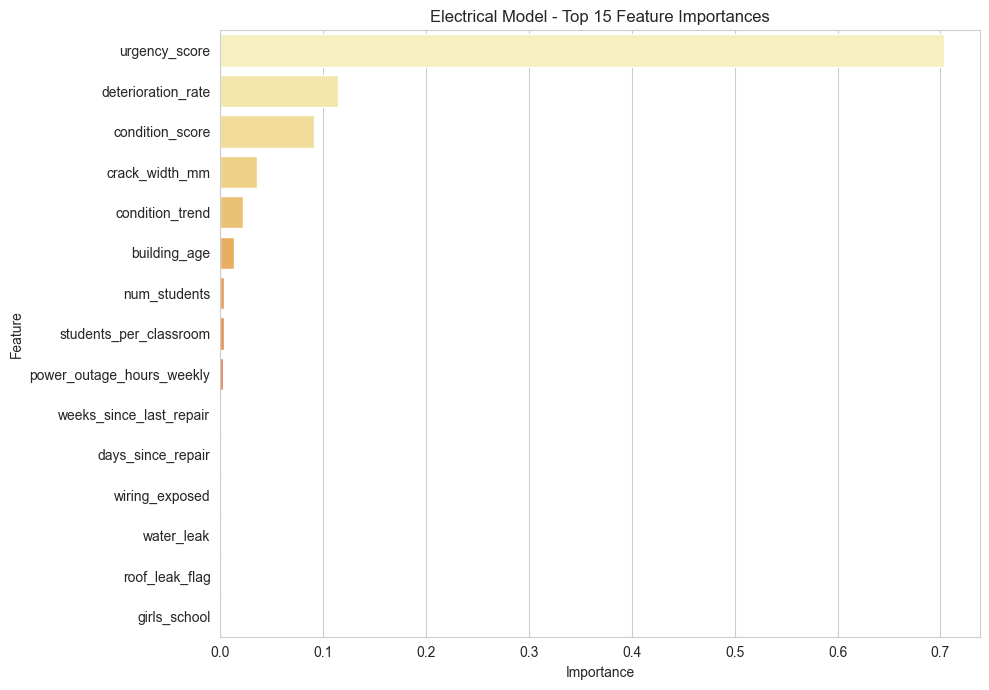

Top 10 features:
  urgency_score                  0.7032
  deterioration_rate             0.1149
  condition_score                0.0915
  crack_width_mm                 0.0355
  condition_trend                0.0225
  building_age                   0.0135
  num_students                   0.0037
  students_per_classroom         0.0036
  power_outage_hours_weekly      0.0030
  weeks_since_last_repair        0.0011


In [8]:
feat_imp = pd.DataFrame({
    'Feature': electrical_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='YlOrRd')
plt.title('Electrical Model - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for _, row in feat_imp.head(10).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

In [9]:
def explain_electrical(model, features, feature_names, top_n=5):
    """Returns prediction with explanation."""
    arr = np.array(features).reshape(1, -1)
    pred = model.predict(arr)[0]
    prob = model.predict_proba(arr)[0]
    fail_prob = prob[1]
    risk = 'High' if fail_prob >= 0.7 else ('Medium' if fail_prob >= 0.4 else 'Low')

    imp = model.feature_importances_
    top = sorted(zip(feature_names, features, imp), key=lambda x: x[2], reverse=True)[:top_n]

    labels = {
        'wiring_exposed': 'exposed wiring',
        'power_outage_hours_weekly': 'frequent outages',
        'condition_score': 'poor condition',
        'issue_flag': 'repeated faults',
        'students_per_classroom': 'high student density',
        'weeks_since_last_repair': 'long repair gap',
        'building_age': 'aging infrastructure',
        'water_leak': 'water near electrics',
    }
    reasons = [labels.get(f[0], f[0]) for f in top[:3]]

    return {
        'prediction': int(pred),
        'failure_probability': round(float(fail_prob), 4),
        'risk_level': risk,
        'top_features': [{'name': f[0], 'importance': round(float(f[2]), 4)} for f in top],
        'explanation': f"{risk} electrical risk due to: {', '.join(reasons)}."
    }

sample = X_test.iloc[0].values
result = explain_electrical(rf_model, sample, electrical_features)
print('Example prediction:')
print(json.dumps(result, indent=2))

Example prediction:
{
  "prediction": 1,
  "failure_probability": 0.9952,
  "risk_level": "High",
  "top_features": [
    {
      "name": "urgency_score",
      "importance": 0.7032
    },
    {
      "name": "deterioration_rate",
      "importance": 0.1149
    },
    {
      "name": "condition_score",
      "importance": 0.0915
    },
    {
      "name": "crack_width_mm",
      "importance": 0.0355
    },
    {
      "name": "condition_trend",
      "importance": 0.0225
    }
  ],
  "explanation": "High electrical risk due to: urgency_score, deterioration_rate, poor condition."
}


## 7. Save Model

In [10]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/electrical_model.pkl')
joblib.dump(electrical_features, '../models/electrical_features.pkl')

metrics_dict = {
    'model': 'RandomForestClassifier',
    'category': 'electrical',
    'target': TARGET,
    'n_features': len(electrical_features),
    'accuracy': round(float(accuracy_score(y_test, y_pred)), 4),
    'f1_score': round(float(f1_score(y_test, y_pred)), 4),
    'precision': round(float(precision_score(y_test, y_pred)), 4),
    'recall': round(float(recall_score(y_test, y_pred)), 4),
    'roc_auc': round(float(roc_auc_score(y_test, y_prob)), 4),
    'cv_mean_f1': round(float(cv_scores.mean()), 4),
    'features': electrical_features
}
with open('../models/electrical_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print('Electrical model saved to models/')
print(f'  Accuracy: {metrics_dict["accuracy"]}')
print(f'  F1:       {metrics_dict["f1_score"]}')
print(f'  ROC AUC:  {metrics_dict["roc_auc"]}')

Electrical model saved to models/
  Accuracy: 0.9997
  F1:       0.9996
  ROC AUC:  1.0
